0    1.25372
1    1.23378
2    1.20766
3    1.19457
4    1.17574
Name: SpotPriceDKK, dtype: float64
Loading demand profiles...
Demand profiles loaded!
Loading production data...
Production profiles loaded!
2.535
3.3217833333333333
Loading demand profiles...
Demand profiles loaded!
Loading production data...
Production profiles loaded!


/Users/antonlenander/anaconda3/envs/phantom/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2025-01-21 09:23:15,872	INFO util.py:159 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.
2025-01-21 09:23:15,929	INFO util.py:159 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.
2025-01-21 09:23:16,421	WARNING deprecation.py:50 -- DeprecationWarning: `DirectStepOptimizer` has been deprecated. This will raise an error in the future!


[array([0.], dtype=float32), array([0.09210363], dtype=float32), array([0.02005309], dtype=float32), array([0.], dtype=float32), array([0.11140156], dtype=float32), array([0.06933507], dtype=float32), array([0.], dtype=float32), array([0.02606267], dtype=float32), array([0.19323552], dtype=float32), array([0.], dtype=float32), array([0.], dtype=float32), array([0.30476028], dtype=float32), array([0.03530827], dtype=float32), array([0.], dtype=float32), array([0.29468316], dtype=float32), array([0.12304872], dtype=float32), array([0.], dtype=float32), array([0.09573871], dtype=float32), array([0.3070284], dtype=float32), array([0.], dtype=float32), array([0.], dtype=float32), array([0.53997695], dtype=float32), array([0.0871101], dtype=float32), array([0.], dtype=float32), array([0.], dtype=float32), array([0.09211257], dtype=float32), array([0.02022892], dtype=float32), array([0.], dtype=float32), array([0.1104826], dtype=float32), array([0.06974131], dtype=float32), array([0.], dtype=

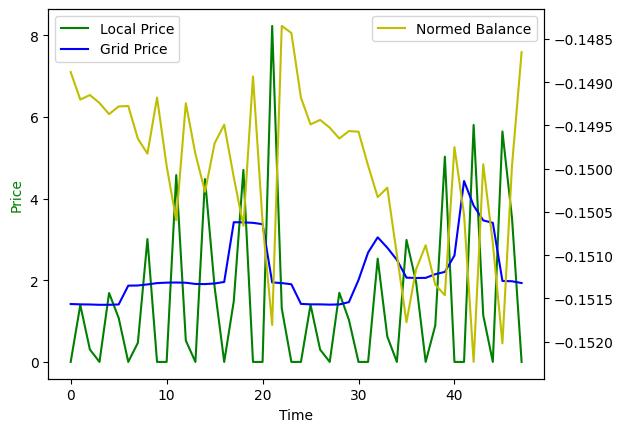

In [ ]:
import matplotlib.pyplot as plt
import cloudpickle
import numpy as np
from datamanager import DataManager

path = "output/flex_balanceonly/results.pkl"
outputfolder = "output/flex_balanceonly/"
dm = DataManager(prod_path='data/eval/pv.csv', demand_path='data/eval/demandprofiles.csv', cap_path='data/eval/caps.csv')
max_price = dm.get_all_max_price() + 2.0666
max_price = max_price * 1.5

with open(path, "rb") as file:
    results = cloudpickle.load(file)

results = list(results)

for rollout in results:

    aid = "CM"
    agent_actions = []
    budget_balance = []
    capacity_balance = []
    cap_limits = []
    total_import = []
    prices = []
    norm_balance = []
    grid_price = []
    rewards = []
    rewards += list(rollout.metrics["cm/rewards"])
    grid_price += list(rollout.metrics["cm/current_grid_price"])
    agent_actions += list(rollout.actions_for_agent(aid))
    norm_balance += list(rollout.metrics["cm/normed_balance"])
    budget_balance += list(rollout.metrics["cm/budget_balance"])
    capacity_balance += list(rollout.metrics["cm/capacity_balance"])
    cap_limits += list(rollout.metrics["cm/capacity_limit"])
    total_import += list(rollout.metrics["cm/total_import"])
    prices += list(rollout.metrics["env/current_price"])

    agent_actions = [action for action in agent_actions if action is not None]

    start = 48*30
    end = start + 48*2

    total_import = total_import[1:] + [0]

    rewards = rewards[start:end:2]
    agent_actions = agent_actions[start:end]
    capacity_balance = capacity_balance[start:end:2]
    cap_limits = cap_limits[start:end:2]
    total_import = total_import[start:end:2]
    norm_balance = norm_balance[start:end:2]
    grid_price = grid_price[start:end:2]

    # agent_actions = agent_actions[start:end]
    # capacity_balance = capacity_balance[start:end]
    # cap_limits = cap_limits[start:end]
    # total_import = total_import[start:end]
    prices = prices[start:end:2]
    budget_balance = budget_balance[start:end:2]
    print(agent_actions)

    fig, ax1 = plt.subplots()

 

    ax2 = ax1.twinx()
    ax1.plot(prices, 'g-', label="Local Price")
    #ax1.plot(agent_actions, 'k-', label="Agent Actions")
    ax1.plot(grid_price, 'b-', label="Grid Price")
    ax2.plot(norm_balance, 'y-', label="Normed Balance")
    #ax2.plot(rewards, 'r-', label="rewards")
    ax2.set_ylim(-1, 1)
    ax1.set_xlabel('Time')
    ax1.set_ylabel('Price', color='g')

    ax1.legend(loc='upper left')
    ax2.legend(loc='upper right')

    plt.show()

    #Plot distribution of agent action per step for all rollouts
    # plt.hist(agent_actions, bins=30, edgecolor='black')
    # prices = np.linspace(0.1, max_price, num=30)
    # print(prices)
    # plt.xticks(prices)
    # plt.title("Distribution of action values")
    # plt.xlabel("Agent action")
    # plt.ylabel("Frequency")
    # plt.savefig(f"action_dist_{aid}.png")
    # plt.close()
